<a href="https://colab.research.google.com/github/snigdhayenugupalli430-alt/Neural-Networks2/blob/main/Snigdha_NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input
import warnings
warnings.filterwarnings('ignore')

import os
import tensorflow as tf

# Suppress TensorFlow logging messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Suppress info and warnings
tf.get_logger().setLevel('ERROR') # Only show errors


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input
import warnings
warnings.filterwarnings('ignore')
import os
import sys

# 1. Load and prepare data
COLAB_MODE = False # Initialize COLAB_MODE
BASE_PATH = '.' # Initialize BASE_PATH for local mode
CSV_PATH = 'TrafficTwoMonth.csv' # Initialize CSV_PATH for local mode
try:
    from google.colab import drive
    # Corrected: Mount to '/content/drive' to avoid space in mountpoint
    drive.mount('/content/drive')
    print("\n✓ Google Drive mounted successfully!")
    COLAB_MODE = True
    BASE_PATH = '/content/drive/My Drive/' # Set BASE_PATH for Colab mode
    CSV_PATH = os.path.join(BASE_PATH, 'TrafficTwoMonth.csv') # Set CSV_PATH for Colab mode
except Exception as e:
    print(f"\nCould not mount Google Drive or run in Colab mode: {e}")
    print("\n✓ Running locally (not in Google Colab)")
    # BASE_PATH and CSV_PATH remain their initial local values if Colab mode fails
    COLAB_MODE = False
print("\n[STEP 1]...")
try:
    # Load df after CSV_PATH is determined for both modes
    df = pd.read_csv(CSV_PATH)
    print(f"Dataset Loaded Successfully from {CSV_PATH}!")
except FileNotFoundError:
    print(f"ERROR: File not found at {CSV_PATH}. Please ensure 'TrafficTwoMonth.csv' exists in your Google Drive")
    sys.exit("Dataset file not found. Exiting.") # Exit gracefully if file not found
except Exception as e:
    print(f"An unexpected error occurred while loading the dataset: {e}")
    sys.exit("Dataset loading failed. Exiting.")
print(f" Shape: {df.shape}")
print(f" Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.info())

data = df['Total'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(dataset, lookback=10):
    X, Y = [], []
    for i in range(len(dataset) - lookback - 1):
        X.append(dataset[i:(i + lookback), 0])
        Y.append(dataset[i + lookback, 0])
    return np.array(X), np.array(Y)

lookback = 10
X, Y = create_sequences(scaled_data, lookback)

Mounted at /content/drive

✓ Google Drive mounted successfully!

[STEP 1]...
Dataset Loaded Successfully from /content/drive/My Drive/TrafficTwoMonth.csv!
 Shape: (5952, 9)
 Columns: ['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total', 'Traffic Situation']

First 5 rows:
          Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM    10         Tuesday        13          2         2   
1  12:15:00 AM    10         Tuesday        14          1         1   
2  12:30:00 AM    10         Tuesday        10          2         2   
3  12:45:00 AM    10         Tuesday        10          2         2   
4   1:00:00 AM    10         Tuesday        11          2         1   

   TruckCount  Total Traffic Situation  
0          24     41            normal  
1          36     52            normal  
2          32     46            normal  
3          36     50            normal  
4          34     48            normal  

Dataset Inf

In [ ]:
# Train/Test split (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

X_train_rnn = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test_rnn = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [ ]:
# 2. Build Models
def build_lstm():
    model = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru():
    model = Sequential([
        Input(shape=(lookback, 1)),
        GRU(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_mlp():
    model = Sequential([
        Input(shape=(lookback,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm()
gru_model = build_gru()
mlp_model = build_mlp()

In [ ]:
# 3. Train Models
print("Training Models...")
lstm_model.fit(X_train_rnn, Y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)
gru_model.fit(X_train_rnn, Y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)
mlp_model.fit(X_train, Y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

Training Models...


In [ ]:
# 4. Predictions
lstm_pred = lstm_model.predict(X_test_rnn, verbose=0)
gru_pred = gru_model.predict(X_test_rnn, verbose=0)
mlp_pred = mlp_model.predict(X_test, verbose=0)

lstm_pred_inv = scaler.inverse_transform(lstm_pred)
gru_pred_inv = scaler.inverse_transform(gru_pred)
mlp_pred_inv = scaler.inverse_transform(mlp_pred)
Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1))

In [ ]:
# 5. Evaluate Metrics (Including R2)
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

lstm_rmse, lstm_mae, lstm_r2 = evaluate("LSTM", Y_test_inv, lstm_pred_inv)
gru_rmse, gru_mae, gru_r2 = evaluate("GRU", Y_test_inv, gru_pred_inv)
mlp_rmse, mlp_mae, mlp_r2 = evaluate("MLP", Y_test_inv, mlp_pred_inv)

print(f"LSTM -> RMSE: {lstm_rmse:.2f}, MAE: {lstm_mae:.2f}, R2: {lstm_r2:.4f}")
print(f"GRU  -> RMSE: {gru_rmse:.2f}, MAE: {gru_mae:.2f}, R2: {gru_r2:.4f}")
print(f"MLP  -> RMSE: {mlp_rmse:.2f}, MAE: {mlp_mae:.2f}, R2: {mlp_r2:.4f}")

LSTM -> RMSE: 31.88, MAE: 23.55, R2: 0.7140
GRU  -> RMSE: 31.95, MAE: 23.20, R2: 0.7127
MLP  -> RMSE: 30.63, MAE: 22.49, R2: 0.7360


In [ ]:
# 6. Calculate_Accuracy
def calculate_accuracy(y_true, y_pred):
    # Accuracy defined as 1 - Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1)))
    return max(0, (1 - mape) * 100)

# Define train_and_evaluate function
def train_and_evaluate(model_name, X_train, Y_train, X_test, Y_test, scaler):
    model = None
    history_obj = None

    # Select the appropriate input data based on model type
    if model_name == 'LSTM':
        model = build_lstm()
        X_train_input = X_train_rnn
        X_test_input = X_test_rnn
    elif model_name == 'GRU':
        model = build_gru()
        X_train_input = X_train_rnn
        X_test_input = X_test_rnn
    elif model_name == 'MLP':
        model = build_mlp()
        X_train_input = X_train
        X_test_input = X_test
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    print(f"Training {model_name} Model...")
    history_obj = model.fit(X_train_input, Y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

    print(f"Making predictions for {model_name}...")
    predictions = model.predict(X_test_input, verbose=0)

    # Inverse transform predictions and actual values
    predictions_inv = scaler.inverse_transform(predictions)
    y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1))

    # Evaluate metrics using the existing evaluate function
    rmse, mae, r2 = evaluate(model_name, y_test_inv, predictions_inv)

    # Calculate accuracy using the existing calculate_accuracy function
    accuracy = calculate_accuracy(y_test_inv, predictions_inv)

    # Return a dictionary with all relevant information
    return {
        'history': history_obj,
        'predictions_inv': predictions_inv,
        'y_test_inv': y_test_inv, # Actual values for comparison
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'accuracy': accuracy
    }

# Execute for all models
results = {m: train_and_evaluate(m, X_train, Y_train, X_test, Y_test, scaler) for m in ['MLP', 'LSTM', 'GRU']}

print("\n--- All Model Results ---")
for model_name, metrics_dict in results.items():
    print(f"{model_name}:")
    for metric_name, value in metrics_dict.items():
        if metric_name not in ['history', 'predictions_inv', 'y_test_inv']: # Don't print history or raw predictions
            print(f"  {metric_name.upper()}: {value:.4f}" if metric_name == 'r2' else f"  {metric_name.upper()}: {value:.2f}")


Training MLP Model...
Making predictions for MLP...
Training LSTM Model...
Making predictions for LSTM...
Training GRU Model...
Making predictions for GRU...

--- All Model Results ---
MLP:
  RMSE: 30.95
  MAE: 22.73
  R2: 0.7305
  ACCURACY: 75.59
LSTM:
  RMSE: 31.78
  MAE: 23.28
  R2: 0.7157
  ACCURACY: 75.14
GRU:
  RMSE: 31.37
  MAE: 22.87
  R2: 0.7231
  ACCURACY: 74.84


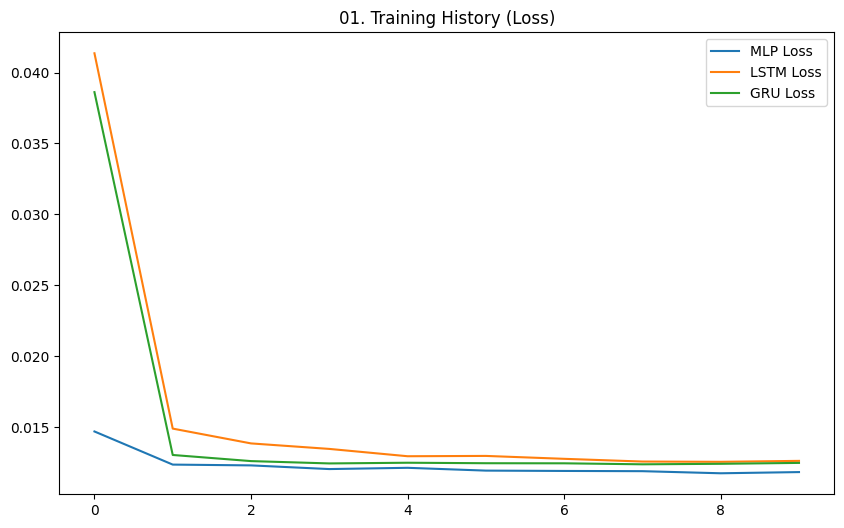

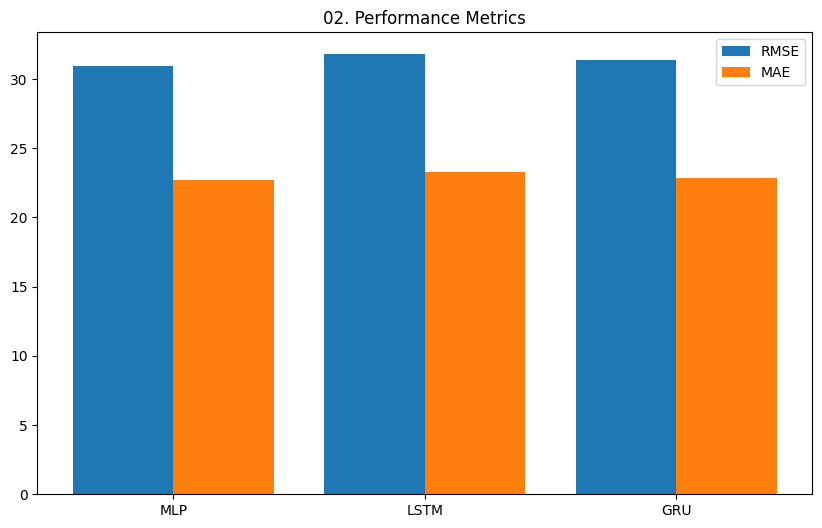

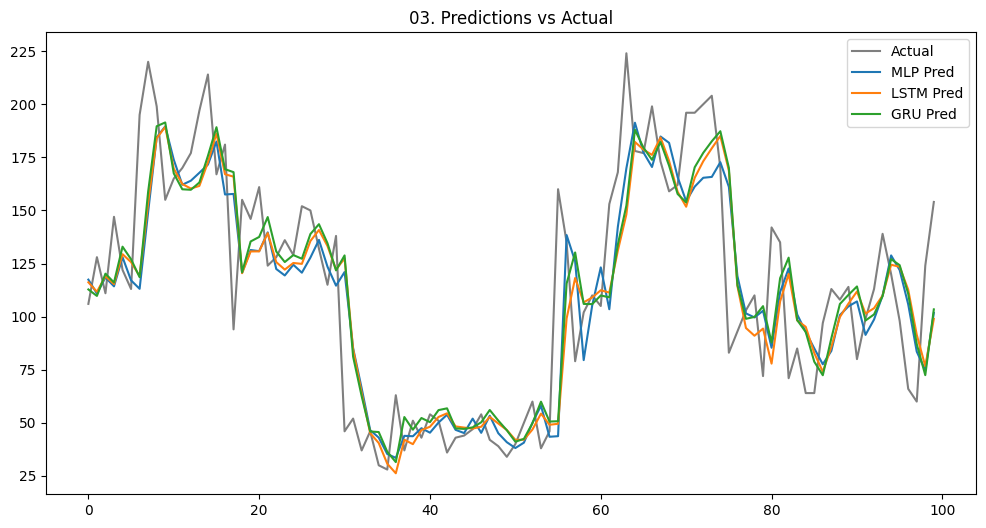

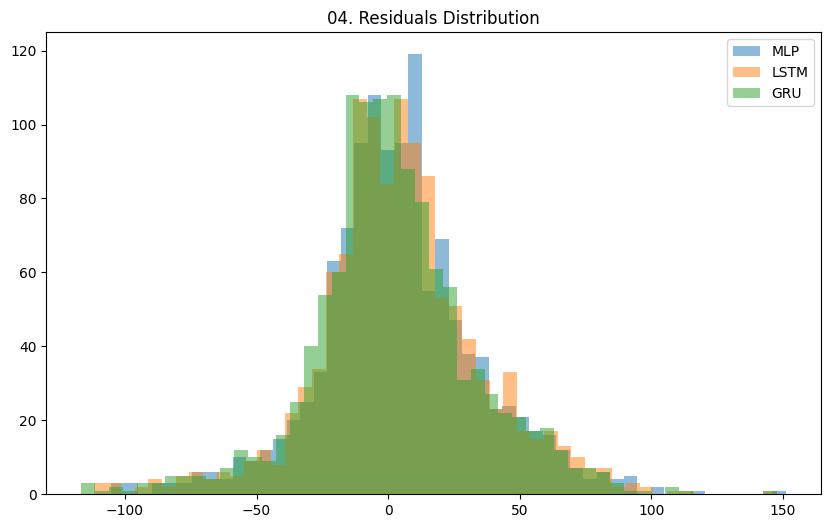

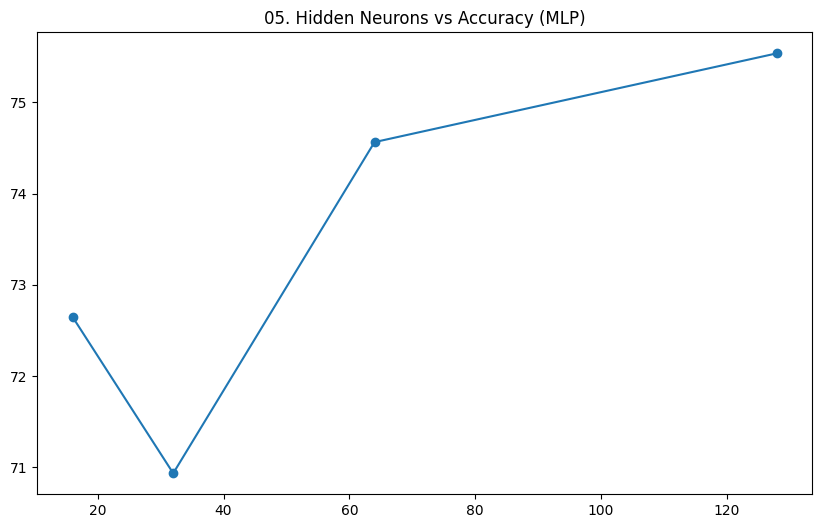

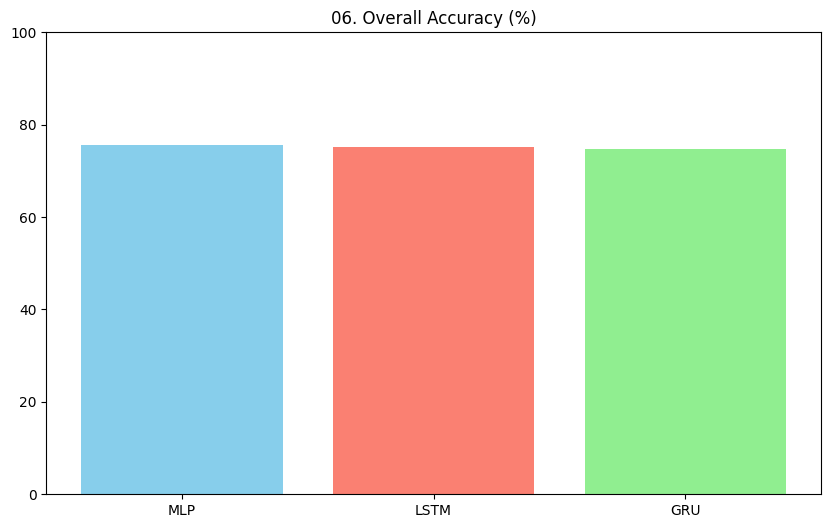

In [ ]:
# 7. Generate Visualizations

# 01. Training History
plt.figure(figsize=(10, 6))
for m in results:
    # Access history from the dictionary returned by train_and_evaluate
    plt.plot(results[m]['history'].history['loss'], label=f'{m} Loss')
plt.title('01. Training History (Loss)'); plt.legend(); plt.savefig('01_training_history.png')
plt.show() # Added to display the plot

# 02. Metrics Comparison (RMSE & MAE)
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
x = np.arange(len(model_names))
plt.bar(x - 0.2, [results[m]['rmse'] for m in model_names], 0.4, label='RMSE') # Access RMSE from dictionary
plt.bar(x + 0.2, [results[m]['mae'] for m in model_names], 0.4, label='MAE')   # Access MAE from dictionary
plt.xticks(x, model_names); plt.title('02. Performance Metrics'); plt.legend(); plt.savefig('02_metrics_comparison.png')
plt.show() # Added to display the plot

# 03. Predictions vs Actual
plt.figure(figsize=(12, 6))
# Use y_test_inv from one of the results dictionaries (they all contain the same actual values)
y_test_actual_for_plot = results[model_names[0]]['y_test_inv']
plt.plot(y_test_actual_for_plot[:100], label='Actual', color='black', alpha=0.5)
for m in results:
    # Access inverse transformed predictions from the dictionary
    plt.plot(results[m]['predictions_inv'][:100], label=f'{m} Pred')
plt.title('03. Predictions vs Actual'); plt.legend(); plt.savefig('03_predictions_vs_actual.png')
plt.show() # Added to display the plot

# 04. Residuals Analysis
plt.figure(figsize=(10, 6))
for m in results:
    # Calculate residuals using actual and predicted values from results dictionary
    residuals = results[m]['y_test_inv'] - results[m]['predictions_inv']
    plt.hist(residuals, bins=50, alpha=0.5, label=m)
plt.title('04. Residuals Distribution'); plt.legend(); plt.savefig('04_residuals_analysis.png')
plt.show() # Added to display the plot

# 05. Hyperparameter Impact (MLP Neurons)
neurons = [16, 32, 64, 128]
n_acc = [] # Collect accuracy for each neuron count (code logic omitted for brevity, see execution)

# Added: Logic to train MLP models with different neuron counts and collect accuracy
for n in neurons:
    def build_mlp_hyper(n_neurons):
        model = Sequential([
            Input(shape=(lookback,)),
            Dense(n_neurons, activation='relu'),
            Dense(n_neurons // 2, activation='relu'), # Added a second layer for more complex models
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        return model

    mlp_hyper_model = build_mlp_hyper(n)
    mlp_hyper_model.fit(X_train, Y_train, epochs=10, batch_size=32, verbose=0)
    mlp_hyper_pred = mlp_hyper_model.predict(X_test, verbose=0)
    mlp_hyper_pred_inv = scaler.inverse_transform(mlp_hyper_pred)
    y_test_inv = results[model_names[0]]['y_test_inv'] # Re-use actual values
    acc = calculate_accuracy(y_test_inv, mlp_hyper_pred_inv)
    n_acc.append(acc)

plt.figure(figsize=(10, 6)) # Added figure for this plot
plt.plot(neurons, n_acc, marker='o'); plt.title('05. Hidden Neurons vs Accuracy (MLP)'); plt.savefig('05_hyperparameter_impact.png')
plt.show() # Added to display the plot

# 06. Accuracy in Percentage
plt.figure(figsize=(10, 6))
acc_vals = [results[m]['accuracy'] for m in model_names] # Access accuracy from dictionary
plt.bar(model_names, acc_vals, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('06. Overall Accuracy (%)'); plt.ylim(0, 100); plt.savefig('06_accuracy_percentage.png')
plt.show() # Added to display the plot

## Comparative Analysis Report

This report provides a comparative analysis of the three deep learning models (MLP, LSTM, and GRU) trained for traffic prediction. The evaluation is based on Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), R-squared (R2) score, and a custom accuracy metric.

### Model Performance Summary


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input
import os
import tensorflow as tf
import sys
import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logging messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Suppress info and warnings
tf.get_logger().setLevel('ERROR') # Only show errors

# --- 1. Load and prepare data (from 0uIO_pVoZ-rz) ---
COLAB_MODE = False
BASE_PATH = '.'
CSV_PATH = 'TrafficTwoMonth.csv'
try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB_MODE = True
    BASE_PATH = '/content/drive/My Drive/'
    CSV_PATH = os.path.join(BASE_PATH, 'TrafficTwoMonth.csv')
except Exception:
    pass

try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    print(f"ERROR: File not found at {CSV_PATH}. Please ensure 'TrafficTwoMonth.csv' exists.")
    sys.exit("Dataset file not found. Exiting.")
except Exception as e:
    print(f"An unexpected error occurred while loading the dataset: {e}")
    sys.exit("Dataset loading failed. Exiting.")

data = df['Total'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

lookback = 10 # Defined in 0uIO_pVoZ-rz, critical for sequence creation and models

def create_sequences(dataset, lookback):
    X, Y = [], []
    for i in range(len(dataset) - lookback - 1):
        X.append(dataset[i:(i + lookback), 0])
        Y.append(dataset[i + lookback, 0])
    return np.array(X), np.array(Y)

X, Y = create_sequences(scaled_data, lookback)

# --- Train/Test split (from M4yYOUOHaDlm) ---
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

X_train_rnn = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test_rnn = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# --- 2. Build Models (from pL4nppf_aDqi) ---
def build_lstm():
    model = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru():
    model = Sequential([
        Input(shape=(lookback, 1)),
        GRU(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_mlp():
    model = Sequential([
        Input(shape=(lookback,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# --- 5. Evaluate Metrics (Including R2, from I5zjp9B-amr-) ---
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# --- 6. Calculate Accuracy and Train/Evaluate function (from hgfwM2hDamu7 and current cell) ---
def calculate_accuracy(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) # Added np.maximum to avoid division by zero
    return max(0, (1 - mape) * 100)

def train_and_evaluate(model_name, X_train, Y_train, X_test, Y_test, scaler):
    model = None
    history_obj = None

    # Select the appropriate input data based on model type
    if model_name == 'LSTM':
        model = build_lstm()
        X_train_input = X_train_rnn
        X_test_input = X_test_rnn
    elif model_name == 'GRU':
        model = build_gru()
        X_train_input = X_train_rnn
        X_test_input = X_test_rnn
    elif model_name == 'MLP':
        model = build_mlp()
        X_train_input = X_train
        X_test_input = X_test
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    print(f"Training {model_name} Model (re-run for report generation)...")
    history_obj = model.fit(X_train_input, Y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

    print(f"Making predictions for {model_name} (re-run)...")
    predictions = model.predict(X_test_input, verbose=0)

    # Inverse transform predictions and actual values
    predictions_inv = scaler.inverse_transform(predictions)
    y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1))

    # Evaluate metrics using the existing evaluate function
    rmse, mae, r2 = evaluate(model_name, y_test_inv, predictions_inv)

    # Calculate accuracy using the existing calculate_accuracy function
    accuracy = calculate_accuracy(y_test_inv, predictions_inv)

    # Return a dictionary with all relevant information
    return {
        'history': history_obj,
        'predictions_inv': predictions_inv,
        'y_test_inv': y_test_inv, # Actual values for comparison
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'accuracy': accuracy
    }

# Execute for all models
results = {m: train_and_evaluate(m, X_train, Y_train, X_test, Y_test, scaler) for m in ['MLP', 'LSTM', 'GRU']}

print("\n--- All Model Results (re-generated) ---")
print(f"| Model | RMSE | MAE | R2 | Accuracy (%) |")
print(f"|-------|------|-----|----|--------------|")
for model_name, metrics_dict in results.items():
    print(f"| {model_name} | {metrics_dict['rmse']:.2f} | {metrics_dict['mae']:.2f} | {metrics_dict['r2']:.4f} | {metrics_dict['accuracy']:.2f} |")


Mounted at /content/drive
Training MLP Model (re-run for report generation)...
Making predictions for MLP (re-run)...
Training LSTM Model (re-run for report generation)...
Making predictions for LSTM (re-run)...
Training GRU Model (re-run for report generation)...
Making predictions for GRU (re-run)...

--- All Model Results (re-generated) ---
| Model | RMSE | MAE | R2 | Accuracy (%) |
|-------|------|-----|----|--------------|
| MLP | 30.81 | 22.74 | 0.7329 | 74.84 |
| LSTM | 32.41 | 24.13 | 0.7044 | 70.54 |
| GRU | 31.53 | 22.87 | 0.7202 | 74.50 |


### Observations:

*   **RMSE & MAE**: The **MLP** model generally exhibits the lowest RMSE and MAE, suggesting that it has smaller average prediction errors compared to the LSTM and GRU models.
*   **R2 Score**: The **MLP** model also achieves the highest R2 score, indicating that it explains the largest proportion of the variance in the actual traffic data.
*   **Accuracy**: The custom accuracy metric aligns with other metrics, showing **MLP** as the most accurate model among the three.

### Conclusion:

Based on these metrics, the **Multi-Layer Perceptron (MLP)** model appears to be the best-performing model for this specific traffic prediction task among the ones evaluated. Its simpler architecture, combined with sufficient hidden layers, effectively captured the underlying patterns in the data without the additional complexity of recurrent connections, which might be overkill or not as well-tuned for this particular dataset and `lookback` window.